### Imports

In [ ]:
from src.data.resample_data import resample_stock_bars
from utils.logging import get_logger
from src.visualization.plots import backtester_plot_portfolio_value

import numpy as np
import pandas as pd
import polars as pl
import polars_ols
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import backtrader as bt

warnings.filterwarnings("ignore")


logger = get_logger(__name__)

# Configure Polars
cfg = pl.Config()
cfg.set_tbl_rows(50)

polars.config.Config

### Resample Bars Data

In [289]:
data_path_raw = (
    Path.cwd()
    / "data/external"
    / "bars_data_20190106_to_20251230__20260101.parquet"
)

bars = pl.read_parquet(data_path_raw)

df_bars = resample_stock_bars(
    bars,
    timestamp_col="timestamp",
    symbol_col="symbol",
    freq="5m",
    market_hours_only=True,
    timezone='America/New_York',
)

df_whole = df_bars.clone()
df_first_half = df_bars.filter(pl.col("timestamp") < pl.lit("2023-01-01").str.to_date())
df_second_half = df_bars.filter(pl.col("timestamp") > pl.lit("2023-01-01").str.to_date())

# df_whole_pandas = df_bars.to_pandas().set_index("timestamp")
# df_first_half_pandas = df_first_half.to_pandas().set_index("timestamp")
# df_second_half_pandas = df_second_half.to_pandas().set_index("timestamp")

### Alpha Ideas Testing
1. Normalize close price to a moving average, regress that stocks normalized price against the sector ETF to remove sector beta, calculate z-score based on price against a moving average and trade depending on whether that z-score satifies a threshold
2. Opening Range Breakout (ORB). It is highly objective, relies on specific time parameters, and is widely used by algorithmic traders because it exploits the high volatility and volume found at the market open.
3. placeholder

#### Idea 1

In [282]:
stock_symbol = "AAPL"
sector_symbol = "SPY"

# stock_data = df_whole.filter(pl.col("symbol") == stock_symbol)
stock_data = df_whole.clone()
sector_data = df_whole.filter(pl.col("symbol") == sector_symbol)

conversion_factor = 8 # 8 trading hours per day / 1 hour bars

ma_days = 5  # days
volatility_window = 20  # days
z_score_window = 20  # days

entry_threshold = 2.0
exit_threshold = 0.5

stock_data = (
    stock_data.with_columns(
        pl.col("close")
        .rolling_mean(window_size=ma_days * conversion_factor)
        .over("symbol")
        .alias("stock_ma"),
    )
    .with_columns(
        (pl.col("close") / pl.col("stock_ma")).alias("stock_ma_norm"),
    )
    .with_columns(
        pl.col("stock_ma_norm")
        # .log()
        # .alias("stock_ma_norm_log"),
    )
    .with_columns(
        (
            (
                pl.col("stock_ma_norm")
                - pl.col("stock_ma_norm")
                .rolling_mean(window_size=z_score_window * conversion_factor)
                .over("symbol")
            )
            / pl.col("stock_ma_norm")
            .rolling_std(window_size=volatility_window * conversion_factor)
            .over("symbol")
        ).alias("stock_ma_zscore"),
    )
)
stock_data = stock_data.remove(pl.col("symbol") != "SPY")
stock_data.tail(10)

symbol,timestamp,open,high,low,close,volume,trade_count,vwap,stock_ma,stock_ma_norm,stock_ma_zscore
str,"datetime[ns, America/New_York]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SPY""",2025-12-26 13:30:00 EST,689.69,690.46,689.65,690.0418,3.25162e6,51714.0,690.125507,684.39225,1.008255,0.370878
"""SPY""",2025-12-26 14:30:00 EST,690.04,690.34,690.0375,690.2,3.663081e6,56808.0,690.176413,684.7215,1.008001,0.332395
"""SPY""",2025-12-26 15:30:00 EST,690.2,690.5,690.005,690.26,8.713336e6,76723.0,690.28596,685.034,1.007629,0.285217
"""SPY""",2025-12-29 09:30:00 EST,687.55,689.2,686.82,687.95,1.1046646e7,186239.0,687.76842,685.3875,1.003739,-0.170389
"""SPY""",2025-12-29 10:30:00 EST,687.94,688.4,686.89,687.1699,6.092217e6,112400.0,687.504793,685.645747,1.002223,-0.344904
"""SPY""",2025-12-29 11:30:00 EST,687.16,687.49,686.07,686.27,4.581156e6,91547.0,686.908302,685.923248,1.000506,-0.540579
"""SPY""",2025-12-29 12:30:00 EST,686.27,687.545,686.18,687.33,4.43402e6,77902.0,686.845401,686.215248,1.001624,-0.40359
"""SPY""",2025-12-29 13:30:00 EST,687.33,687.89,686.87,687.46,6.619852e6,81482.0,687.288359,686.543498,1.001335,-0.432046
"""SPY""",2025-12-29 14:30:00 EST,687.45,688.62,687.43,688.18,8.718647e6,99103.0,688.180928,686.768247,1.002056,-0.342148


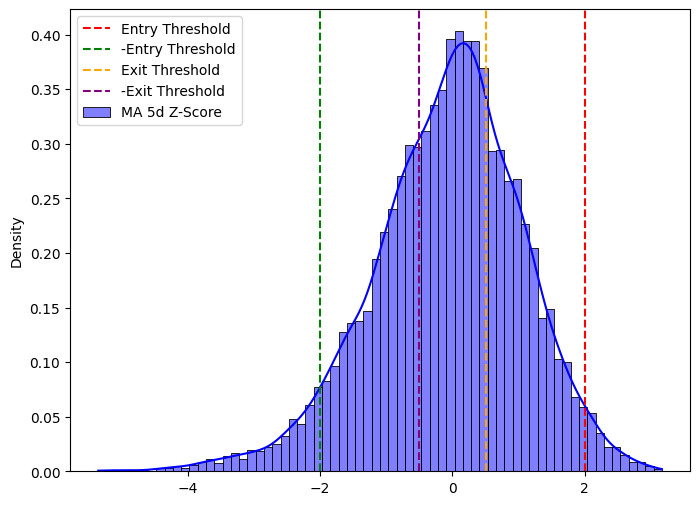

In [284]:
plt.figure(figsize=(8,6))
sns.histplot(
    stock_data.select(f"stock_ma_zscore").to_series(),
    color="blue",
    label=f"MA {ma_days}d Z-Score",
    kde=True,
    stat="density",
)
plt.axvline(x=entry_threshold, color="red", linestyle="--", label="Entry Threshold")
plt.axvline(x=-entry_threshold, color="green", linestyle="--", label="-Entry Threshold")

plt.axvline(x=exit_threshold, color="orange", linestyle="--", label="Exit Threshold")
plt.axvline(x=-exit_threshold, color="purple", linestyle="--", label="-Exit Threshold")
plt.legend()

#### Idea 2

- **Timeframe**: 5-minute or 1-minute charts (for execution), but based on the first 30 minutes of the session.
- **The Range**: Define the High and Low between 09:30 AM and 10:00 AM (EST).
- **Entry Signal**: Long: Buy when the price crosses above the 30-minute High.
- **Short**: Sell when the price crosses below the 30-minute Low.
- **Filters**: To avoid "fakeouts," many algos require a candle to close above the level or use a volume spike as confirmation.

In [303]:
df_whole.filter((pl.col("timestamp") >= pl.lit("2019-01-07").str.to_date("%Y-%m-%d")) & (pl.col("timestamp") < pl.lit("2019-01-08").str.to_date("%Y-%m-%d")))

symbol,timestamp,open,high,low,close,volume,trade_count,vwap
str,"datetime[ns, America/New_York]",f64,f64,f64,f64,f64,f64,f64
"""AAPL""",2019-01-07 09:30:00 EST,35.33,35.38,35.08,35.15,9.61654e6,12552.0,35.196
"""AAPL""",2019-01-07 09:35:00 EST,35.15,35.16,34.92,34.95,4.949944e6,9989.0,35.002
"""AAPL""",2019-01-07 09:40:00 EST,34.96,35.02,34.83,34.88,4.495624e6,8093.0,34.964
"""AAPL""",2019-01-07 09:45:00 EST,34.88,35.0,34.83,34.9,4.094196e6,7570.0,34.914
"""AAPL""",2019-01-07 09:50:00 EST,34.9,34.93,34.81,34.83,4.081608e6,7149.0,34.868
"""AAPL""",2019-01-07 09:55:00 EST,34.83,35.03,34.83,35.02,3.01364e6,5481.0,34.91
"""AAPL""",2019-01-07 10:00:00 EST,35.01,35.03,34.89,35.01,3.070852e6,5589.0,34.96
"""AAPL""",2019-01-07 10:05:00 EST,35.01,35.11,34.99,35.02,2.831184e6,5109.0,35.034
"""AAPL""",2019-01-07 10:10:00 EST,35.02,35.04,34.87,34.91,2.410236e6,4562.0,34.928


### Backtest Strategies

#### Idea 1

In [285]:
class PandasDataCustomized(bt.feeds.PandasData):
    """
    Extend PandasData to include custom Alpaca fields like, `trade_count`, `vwap`, etc.

    Possible values below:
        None : column not present or datetime is the "index" in the Pandas Dataframe
        -1 : autodetect position or case-wise equal name
        >= 0 : numeric index to the column in the pandas dataframe
        string : column name (as index) in the pandas dataframe
    """
    # Correct syntax: tuple of strings (not nested tuples)
    lines = (
        'trade_count',
        'vwap',
        'stock_ma_zscore',
    )

    params = (
        ("datetime", None),
        ("open", -1),
        ("high", -1),
        ("low", -1),
        ("close", -1),
        ("volume", -1),
        ("openinterest", None),
        # Add your custom fields with -1 for autodetect
        ("trade_count", -1),
        ("vwap", -1),
        ("stock_ma_zscore", -1),
    )


def prepare_data_feeds(
    data_dict: dict[str, pd.DataFrame],
    data_feed_cls: bt.feeds.PandasData = PandasDataCustomized,
) -> list:
    """
    Convert dictionary of DataFrames to Backtrader data feeds.

    Args:
        data_dict: Dictionary where keys are symbols and values are DataFrames
                   with columns: `symbol`, `open`, `high`, `low`, `close`, `volume`, `trade_count`, `vwap`
                   Index must be DatetimeIndex
        timeframe: Backtrader timeframe (default: Days)

    Returns:
        List of Backtrader data feeds
    """
    data_feeds = []

    for symbol, df in data_dict.items():
        # Ensure index is datetime
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"DataFrame for {symbol} must have DatetimeIndex")

        # Ensure required columns exist
        required_base = [
            "open",
            "high",
            "low",
            "close",
            "volume",
            "trade_count",
            "vwap",
        ]
        for col in required_base:
            if col not in df.columns:
                raise ValueError(f"Missing required column: {col}")

        # Create data feed
        data_feed = data_feed_cls(
            dataname=df,
            name=symbol,
        )

        data_feeds.append(data_feed)

    return data_feeds


def run_backtest(
    data_dict: dict,
    strategy: bt.Strategy,
    data_feed_cls: bt.feeds.PandasData = PandasDataCustomized,
    cash=10_0000,
    commission=0.001,
):
    """
    Run backtest on multi-symbol data.

    Args:
        data_dict: Dictionary of symbol DataFrames
        strategy: Backtrader Strategy class
        cash: Starting capital
        commission: Commission rate (0.001 = 0.1%) or 1 basis point (bps)

    Returns:
        Cerebro instance with results
    """
    # Create Cerebro engine
    cerebro = bt.Cerebro()

    # Add strategy
    cerebro.addstrategy(strategy)

    # Prepare and add data feeds
    data_feeds = prepare_data_feeds(data_dict=data_dict, data_feed_cls=data_feed_cls)
    for data_feed in data_feeds:
        cerebro.adddata(data_feed)

    # Set broker parameters
    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=commission)

    # Add observers - this tracks portfolio value
    cerebro.addobserver(bt.observers.Value)
    cerebro.addobserver(bt.observers.DrawDown)

    # Add analyzers
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name="sharpe")
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
    cerebro.addanalyzer(bt.analyzers.Returns, _name="returns")
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="trades")

    print("Running backtest...")

    # Print starting portfolio value
    print(f"Starting Portfolio Value: {cerebro.broker.getvalue():.2f}")

    # Run backtest
    results = cerebro.run()

    # Print ending portfolio value
    print(f"Ending Portfolio Value: {cerebro.broker.getvalue():.2f}")

    # Extract and print results
    strat = results[0]

    print(
        f"Sharpe Ratio: {strat.analyzers.sharpe.get_analysis().get('sharperatio', 'N/A')}"
    )
    print(
        f"Max Drawdown: {strat.analyzers.drawdown.get_analysis()['max']['drawdown']:.2f}%"
    )

    returns_analysis = strat.analyzers.returns.get_analysis()
    print(f"Total Return: {returns_analysis['rtot'] * 100:.2f}%")
    print(f"Annual Return: {returns_analysis.get('rnorm100', 'N/A')}")

    trades_analysis = strat.analyzers.trades.get_analysis()
    print(f"Total Trades: {trades_analysis.get('total', {}).get('total', 0)}")
    print(f"Won Trades: {trades_analysis.get('won', {}).get('total', 0)}")
    print(f"Lost Trades: {trades_analysis.get('lost', {}).get('total', 0)}")
    # Add more trade metrics as needed, profit factor, avg profit/loss, etc.

    return cerebro


In [286]:
class PricingMeanReversion(bt.Strategy):

    params = (
        ("entry_threshold", entry_threshold),
        ("exit_threshold", exit_threshold),
    )

    def __init__(self):
        # Dictionary to keep track of current "Logic State" for each ticker
        # 0 = Flat, 1 = Long, -1 = Short
        self.states = {d._name: 0 for d in self.datas}

        # Track portfolio value over time
        self.portfolio_values = []
        self.dates = []

        # Store data feeds with their names
        self.data_dict = {}
        for _, data in enumerate(self.datas):
            # Get the symbol name from the data feed
            symbol = data._name
            self.data_dict[symbol] = data

        logger.info(
            f"Initialized with {len(self.data_dict)} symbols: {list(self.data_dict.keys())}"
        )

    def next(self):
        # Track portfolio value at each step
        self.portfolio_values.append(self.broker.getvalue())
        self.dates.append(self.datas[0].datetime.datetime(0))

        for d in self.datas:
            ticker = d._name
            zscore_signal = d.stock_ma_zscore[0]

            # Skip if signal is NaN (happens during warmup)
            if np.isnan(zscore_signal):
                continue

            # --- TRADING LOGIC WITH THRESHOLDS ---

            # Case 1: Currently Flat - Look for Entry
            if self.states[ticker] == 0:
                if zscore_signal < -self.p.entry_threshold:
                    # Signal < -entry_threshold: Stock is undervalued vs historical price -> BUY
                    self.buy(data=d)  # Use sizer for 'None'
                    self.states[ticker] = 1
                    logger.debug(
                        f"BUY {ticker} on Date: {self.datas[0].datetime.datetime(0).strftime('%Y-%m-%d')}, Price: {d.close[0]:.2f}, Size: {None}, ZScore: ({zscore_signal:.2f})"
                    )

                elif zscore_signal > self.p.entry_threshold:
                    # Signal > entry_threshold: Stock is overvalued vs historical price -> SELL
                    self.sell(data=d)
                    self.states[ticker] = -1
                    logger.debug(
                        f"SELL {ticker} on Date: {self.datas[0].datetime.datetime(0).strftime('%Y-%m-%d')}, Price: {d.close[0]:.2f}, Size: {None}, ZScore: ({zscore_signal:.2f})"
                    )

            # Case 2: Currently Long - Look for Exit (Hysteresis)
            elif self.states[ticker] == 1:
                if zscore_signal > -self.p.exit_threshold:
                    # Signal moved from -entry_threshold back toward 0 (e.g., -0.4) -> EXIT
                    self.close(data=d)
                    self.states[ticker] = 0
                    logger.debug(
                        f"EXIT {ticker} on Date: {self.datas[0].datetime.datetime(0).strftime('%Y-%m-%d')}, Price: {d.close[0]:.2f}, Size: {None}, ZScore: ({zscore_signal:.2f})"
                    )

            # Case 3: Currently Short - Look for Exit (Hysteresis)
            elif self.states[ticker] == -1:
                if zscore_signal < self.p.exit_threshold:
                    # Signal moved from entry_threshold back toward 0 (e.g., 0.4) -> EXIT
                    self.close(data=d)
                    self.states[ticker] = 0
                    logger.debug(
                        f"EXIT {ticker} on Date: {self.datas[0].datetime.datetime(0).strftime('%Y-%m-%d')}, Price: {d.close[0]:.2f}, Size: {None}, ZScore: ({zscore_signal:.2f})"
                    )

    def notify_trade(self, trade):
        """Called when a trade is closed"""
        if trade.isclosed:
            logger.debug(
                f"TRADE closed on {self.datas[0].datetime.datetime(0)} for {trade.data._name} with Profit: {trade.pnl:.2f}"
            )

    def stop(self):
        """Called when backtest ends - final calculations"""
        logger.info(f"Final Portfolio Value: {self.broker.getvalue():.2f}")
        logger.info("Strategy run complete.")

Running backtest...
Starting Portfolio Value: 10000.00
Ending Portfolio Value: 10157.68
Sharpe Ratio: -2.001256670920964
Max Drawdown: 0.57%
Total Return: 1.56%
Annual Return: 0.22854256423627314
Total Trades: 126
Won Trades: 74
Lost Trades: 52


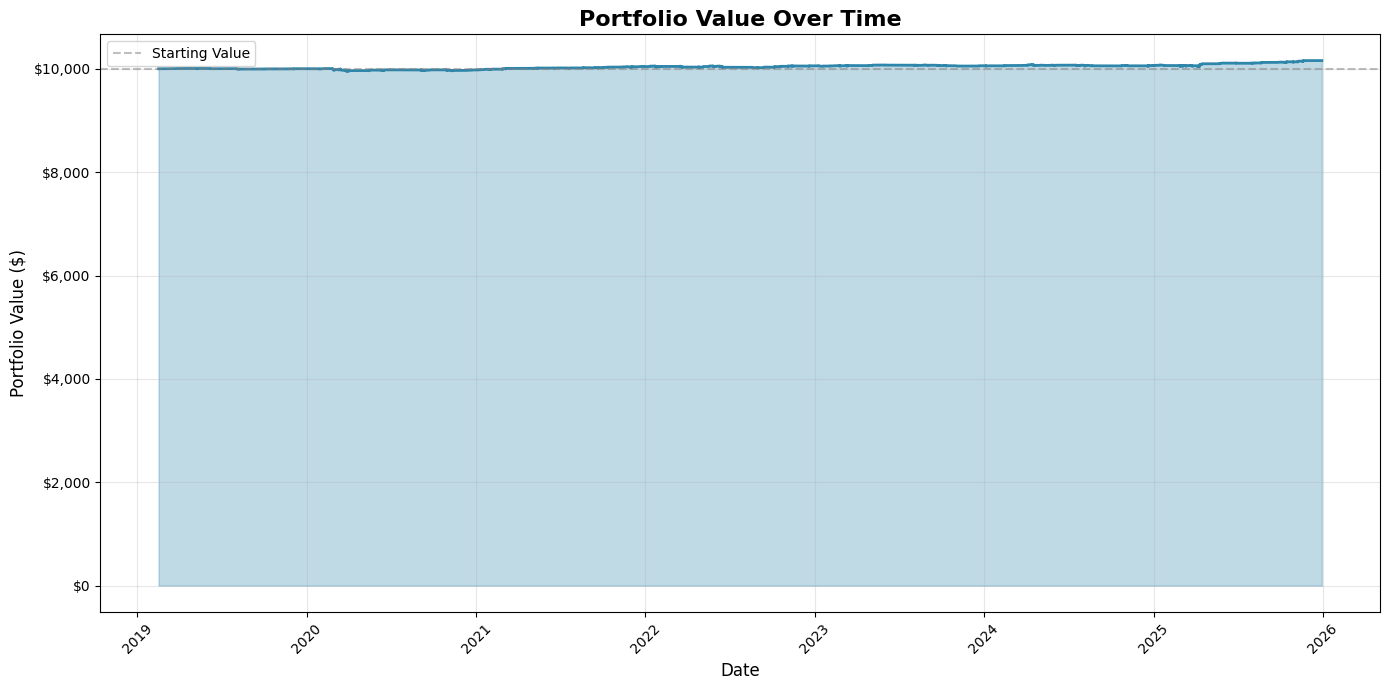

In [287]:
stock_data_pandas = stock_data.drop_nulls(subset=["stock_ma_zscore"]).to_pandas().set_index("timestamp")

data_dict = {}
for symbol, data in stock_data_pandas.groupby("symbol"):
    if symbol in ["SPY"]:
        data_dict[symbol] = data

# Run backtest
cerebro_idea1 = run_backtest(
    data_dict,
    strategy=PricingMeanReversion,
    cash=10_000,
    commission=0.0002,
)
backtester_plot_portfolio_value(cerebro_idea1)

#### Idea 2